<a href="https://colab.research.google.com/github/glwat/Durham_Masters/blob/main/Missing_Data_Imputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#@title Codeblock K001: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [38]:
#@title Codeblock K002: Load Master_Rockfall_2021.xlsx
import pandas as pd

file_path = "/content/drive/MyDrive/Masters_Colab_Data/Master_Rockfall_2021.xlsx"

df = pd.read_excel(file_path, index_col=False)

print(df.info())
print(f"\nRows loaded: {len(df)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8376 entries, 0 to 8375
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ID                    8376 non-null   int64         
 1   Datetime              8376 non-null   datetime64[ns]
 2   Gap_Rockfall          5193 non-null   object        
 3   Gap_hours             258 non-null    float64       
 4   Rockfall_Volume       5193 non-null   float64       
 5   Volume_Error          5193 non-null   float64       
 6   Rockfall_Event_Count  5193 non-null   float64       
 7   Total_Rainfall        8376 non-null   float64       
 8   Air_Temp              8376 non-null   float64       
 9   Relative_Humidity     8376 non-null   float64       
 10  Hourly_Rainfall       8330 non-null   float64       
 11  Thermal_image_name    4071 non-null   object        
 12  TA                    4071 non-null   float64       
 13  Tmean             

In [39]:
#@title Codeblock K003: Drop unused variables
cols_to_drop = [
    "ID", "Total_Rainfall", "Thermal_image_name",
    "Tmeandiff", "Tmindiff", "Tmaxdiff",
    "W1-BSS-Tmean", "W2-IBSS-Tmean",
    "Ref_File", "Rockfall_Occurrence"
]

df = df.drop(columns=cols_to_drop)
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['Datetime', 'Gap_Rockfall', 'Gap_hours', 'Rockfall_Volume', 'Volume_Error', 'Rockfall_Event_Count', 'Air_Temp', 'Relative_Humidity', 'Hourly_Rainfall', 'TA', 'Tmean', 'Tmin', 'Tmax', 'Ref_Mean', 'Ref_Max', 'Ref_Min', 'Ref_Range', 'Ref_sd']


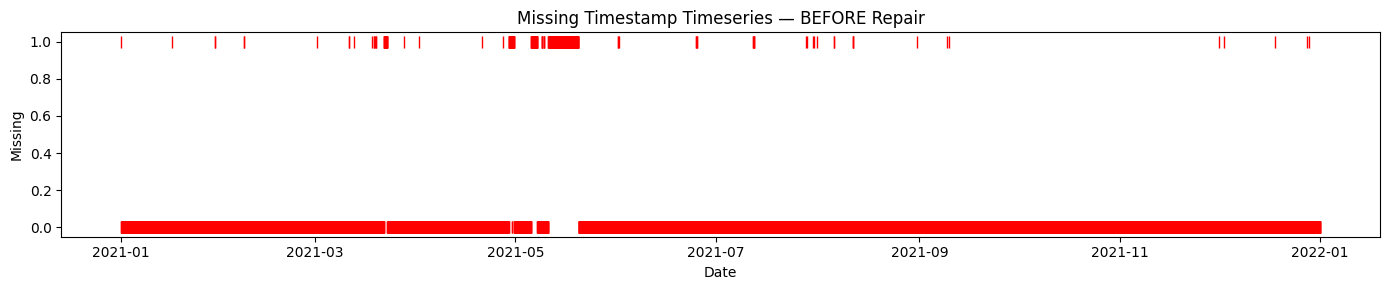

Missing timestamps before repair: 384

Gap Summary BEFORE Repair:
                 Start                 End  Gap_hours
0  2021-01-01 00:00:00 2021-01-01 00:00:00        1.0
1  2021-01-16 09:00:00 2021-01-16 09:00:00        1.0
2  2021-01-29 10:00:00 2021-01-29 11:00:00        2.0
3  2021-02-07 09:00:00 2021-02-07 10:00:00        2.0
4  2021-03-01 15:00:00 2021-03-01 15:00:00        1.0
5  2021-03-11 10:00:00 2021-03-11 11:00:00        2.0
6  2021-03-12 23:00:00 2021-03-12 23:00:00        1.0
7  2021-03-18 08:00:00 2021-03-18 08:00:00        1.0
8  2021-03-19 00:00:00 2021-03-19 01:00:00        2.0
9  2021-03-19 03:00:00 2021-03-19 03:00:00        1.0
10 2021-03-19 12:00:00 2021-03-19 12:00:00        1.0
11 2021-03-19 14:00:00 2021-03-19 14:00:00        1.0
12 2021-03-22 00:00:00 2021-03-22 23:00:00       24.0
13 2021-03-28 01:00:00 2021-03-28 01:00:00        1.0
14 2021-04-01 15:00:00 2021-04-01 15:00:00        1.0
15 2021-04-20 18:00:00 2021-04-20 18:00:00        1.0
16 2021-04-27 05

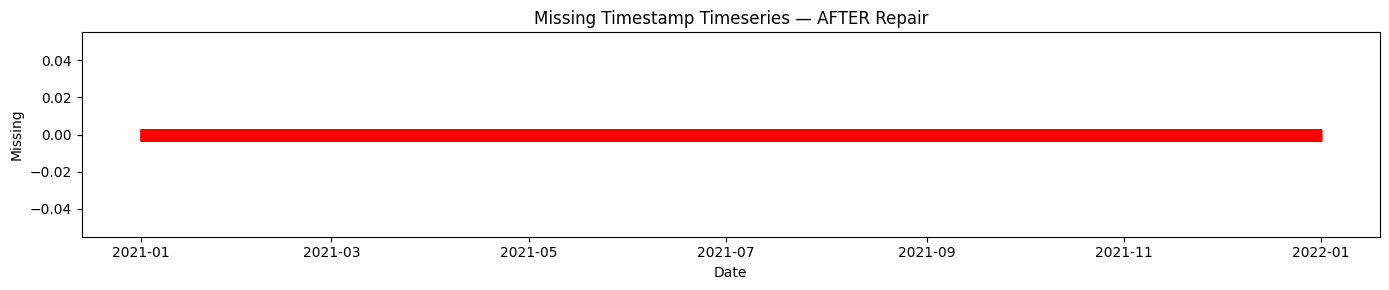

Missing timestamps after repair: 0

Gap Summary AFTER Repair:
Empty DataFrame
Columns: [Start, End, Gap_hours]
Index: []

Timestamp repair complete.


In [40]:
#@title Codeblock K013: Missing Timestamp Diagnostics (Optimized) + Gap Summary

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure datetime + sort
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime")

# Expected hourly timestamps for 2021
expected = pd.date_range(
    start="2021-01-01 00:00:00",
    end="2021-12-31 23:00:00",
    freq="h"
)

def plot_missing_timeseries(df, expected, title):
    """Plot a simple timeseries of missing timestamps."""
    actual = df["Datetime"]
    missing = expected.difference(actual)

    missing_df = pd.DataFrame(index=expected)
    missing_df["Missing"] = 0
    missing_df.loc[missing, "Missing"] = 1

    plt.figure(figsize=(14, 3))
    plt.plot(
        missing_df.index,
        missing_df["Missing"],
        linestyle="none",
        marker="|",
        markersize=8,
        color="red"
    )
    plt.title(title)
    plt.ylabel("Missing")
    plt.xlabel("Date")
    plt.tight_layout()
    plt.show()

    return missing


def gap_length_summary(missing):
    """Return a summary of continuous missing-hour gaps."""
    if len(missing) == 0:
        return pd.DataFrame(columns=["Start", "End", "Gap_hours"])

    missing = pd.Series(missing).sort_values()

    # Identify breaks between consecutive missing timestamps
    gap_id = (missing.diff() != pd.Timedelta(hours=1)).cumsum()

    gaps = (
        missing.groupby(gap_id)
        .agg(Start="first", End="last")
        .reset_index(drop=True)
    )
    gaps["Gap_hours"] = (gaps["End"] - gaps["Start"]) / pd.Timedelta(hours=1) + 1

    return gaps


# ---------------------------------------------------------
# BEFORE FIX
# ---------------------------------------------------------
missing_before = plot_missing_timeseries(
    df, expected,
    "Missing Timestamp Timeseries — BEFORE Repair"
)
print(f"Missing timestamps before repair: {len(missing_before)}")

gap_summary_before = gap_length_summary(missing_before)
print("\nGap Summary BEFORE Repair:")
print(gap_summary_before)


# ---------------------------------------------------------
# INSERT MISSING TIMESTAMPS
# ---------------------------------------------------------
df_full = pd.DataFrame(index=expected)
df_full.index.name = "Datetime"

df = df.set_index("Datetime")
df_full = df_full.join(df)

df = df_full.reset_index()


# ---------------------------------------------------------
# AFTER FIX
# ---------------------------------------------------------
missing_after = plot_missing_timeseries(
    df, expected,
    "Missing Timestamp Timeseries — AFTER Repair"
)
print(f"Missing timestamps after repair: {len(missing_after)}")

gap_summary_after = gap_length_summary(missing_after)
print("\nGap Summary AFTER Repair:")
print(gap_summary_after)

print("\nTimestamp repair complete.")

In [41]:
#@title Codeblock K003: Kalman Smoothing Diagnostics (Optimised)

import pandas as pd
import numpy as np

# Variables to diagnose
vars_to_check = [
    "Air_Temp", "Relative_Humidity", "Hourly_Rainfall",
    "TA", "Tmean", "Tmin", "Tmax",
    "Ref_Mean", "Ref_Max", "Ref_Min", "Ref_Range", "Ref_sd"
]

# Use Datetime as time index
time_index = pd.to_datetime(df["Datetime"])

def largest_gap_info(series, time_index):
    """Return largest consecutive-NaN gap with timestamps."""
    is_na = series.isna().values

    if not is_na.any():
        return 0, None, None

    # Identify boundaries of NA runs
    diff = np.diff(is_na.astype(int))
    starts = np.where(diff == 1)[0] + 1 if is_na[0] == False else np.r_[0, np.where(diff == 1)[0] + 1]
    ends   = np.where(diff == -1)[0] if is_na[-1] == False else np.r_[np.where(diff == -1)[0], len(is_na)-1]

    # Compute lengths
    lengths = ends - starts + 1
    max_idx = np.argmax(lengths)

    return (
        int(lengths[max_idx]),
        time_index[starts[max_idx]],
        time_index[ends[max_idx]]
    )

diagnostics = []

for var in vars_to_check:
    if var not in df.columns:
        diagnostics.append({
            "Variable": var,
            "Exists": False,
            "Missing Count": None,
            "Largest Gap Length": None,
            "Gap Start": None,
            "Gap End": None
        })
        continue

    series = df[var]
    missing_count = series.isna().sum()
    gap_len, gap_start, gap_end = largest_gap_info(series, time_index)

    diagnostics.append({
        "Variable": var,
        "Exists": True,
        "Missing Count": missing_count,
        "Largest Gap Length": gap_len,
        "Gap Start": gap_start,
        "Gap End": gap_end
    })

diagnostics_df = pd.DataFrame(diagnostics)

print("Kalman-Relevant Missing Data Diagnostics:\n")
print(diagnostics_df)

Kalman-Relevant Missing Data Diagnostics:

             Variable  Exists  Missing Count  Largest Gap Length  \
0            Air_Temp    True            384                 221   
1   Relative_Humidity    True            384                 221   
2     Hourly_Rainfall    True            430                 223   
3                  TA    True           4689                 223   
4               Tmean    True           4689                 223   
5                Tmin    True           4689                 223   
6                Tmax    True           4689                 223   
7            Ref_Mean    True           3838                 234   
8             Ref_Max    True           3838                 234   
9             Ref_Min    True           3838                 234   
10          Ref_Range    True           3838                 234   
11             Ref_sd    True           3838                 234   

             Gap Start             Gap End  
0  2021-05-11 00:00:00 2021

In [42]:
#@title Codeblock K005: Prepare Kalman Imputation Columns (Corrected)

import pandas as pd
import numpy as np

vars_to_impute = [
    "Air_Temp", "Relative_Humidity", "Hourly_Rainfall",
    "TA", "Tmean", "Tmin", "Tmax",
    "Ref_Mean", "Ref_Max", "Ref_Min", "Ref_Range", "Ref_sd"
]

# Ensure numeric dtype
for var in vars_to_impute:
    df[var] = pd.to_numeric(df[var], errors="coerce")

# Create _Real and _Kalman columns
for var in vars_to_impute:
    df[f"{var}_Real"] = np.where(df[var].isna(), 0, 1)
    df[f"{var}_Kalman"] = df[var].copy()

print("Prepared numeric, _Real, and _Kalman columns for all variables.")
df.info()

Prepared numeric, _Real, and _Kalman columns for all variables.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 42 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Datetime                  8760 non-null   datetime64[ns]
 1   Gap_Rockfall              5193 non-null   object        
 2   Gap_hours                 258 non-null    float64       
 3   Rockfall_Volume           5193 non-null   float64       
 4   Volume_Error              5193 non-null   float64       
 5   Rockfall_Event_Count      5193 non-null   float64       
 6   Air_Temp                  8376 non-null   float64       
 7   Relative_Humidity         8376 non-null   float64       
 8   Hourly_Rainfall           8330 non-null   float64       
 9   TA                        4071 non-null   float64       
 10  Tmean                     4071 non-null   float64       
 11  Tmin              

In [43]:
#@title Codeblock K010: Seasonal Kalman Smoothing with Data-Driven Q and R (Corrected)

import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.structural import UnobservedComponents

# Only variables that still exist after earlier drops
vars_to_impute = [
    "Air_Temp", "Relative_Humidity", "Hourly_Rainfall",
    "TA", "Tmean", "Tmin", "Tmax",
    "Ref_Mean", "Ref_Max", "Ref_Min", "Ref_Range", "Ref_sd"
]

def estimate_Q(series):
    """State noise variance from first differences."""
    diffs = series.diff().dropna()
    return np.nanvar(diffs)

def estimate_R(series):
    """Observation noise variance from detrended residuals."""
    med = series.rolling(window=24, center=True, min_periods=1).median()
    residuals = series - med
    return np.nanvar(residuals)

def seasonal_kalman_smooth(series, Q, R, seasonal_period=24):
    """Seasonal + local level Kalman smoother with fixed Q and R."""
    model = UnobservedComponents(
        series,
        level="local level",
        seasonal=seasonal_period
    )

    model.update(model.start_params)
    params = model.start_params.copy()

    # Parameter order: [sigma2.irregular, sigma2.level, sigma2.seasonal]
    params[0] = R
    params[1] = Q
    params[2] = Q

    result = model.smooth(params)
    smoothed = result.smoothed_state[0]
    return pd.Series(smoothed, index=series.index)

for var in vars_to_impute:
    print(f"Processing {var}...")

    real_col = f"{var}_Real"
    kalman_col = f"{var}_Kalman"

    s = df[var].astype(float)

    Q = estimate_Q(s)
    R = estimate_R(s)

    smoothed = seasonal_kalman_smooth(s, Q, R, seasonal_period=24)

    observed_min = s.min()
    observed_max = s.max()
    smoothed_clipped = smoothed.clip(lower=observed_min, upper=observed_max)

    df[kalman_col] = np.where(df[real_col] == 1, s, smoothed_clipped)

print("\nSeasonal Kalman smoothing complete.")
df.info()

Processing Air_Temp...
Processing Relative_Humidity...
Processing Hourly_Rainfall...
Processing TA...
Processing Tmean...
Processing Tmin...
Processing Tmax...
Processing Ref_Mean...
Processing Ref_Max...
Processing Ref_Min...
Processing Ref_Range...
Processing Ref_sd...

Seasonal Kalman smoothing complete.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 42 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Datetime                  8760 non-null   datetime64[ns]
 1   Gap_Rockfall              5193 non-null   object        
 2   Gap_hours                 258 non-null    float64       
 3   Rockfall_Volume           5193 non-null   float64       
 4   Volume_Error              5193 non-null   float64       
 5   Rockfall_Event_Count      5193 non-null   float64       
 6   Air_Temp                  8376 non-null   float64       
 7   Relative_Humidity    

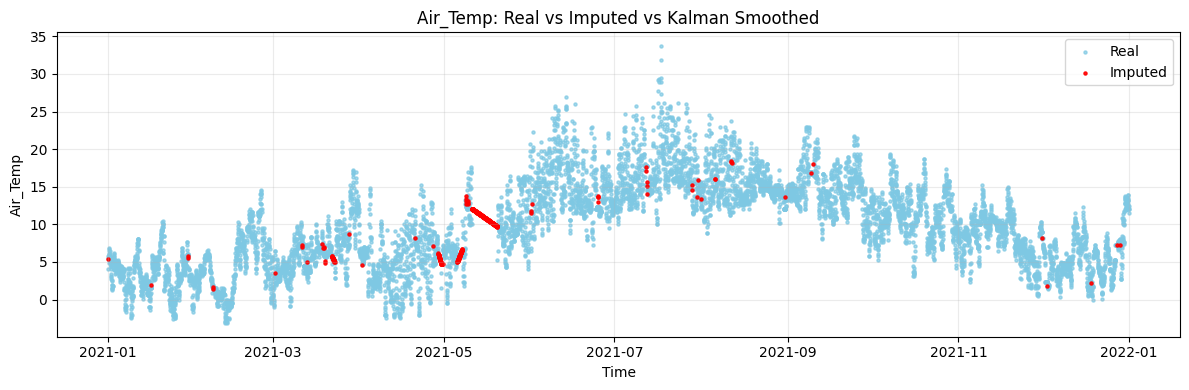

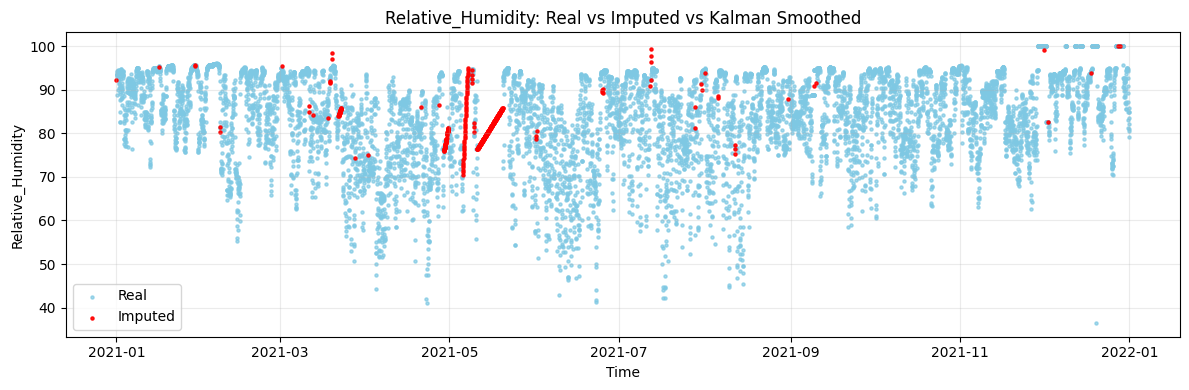

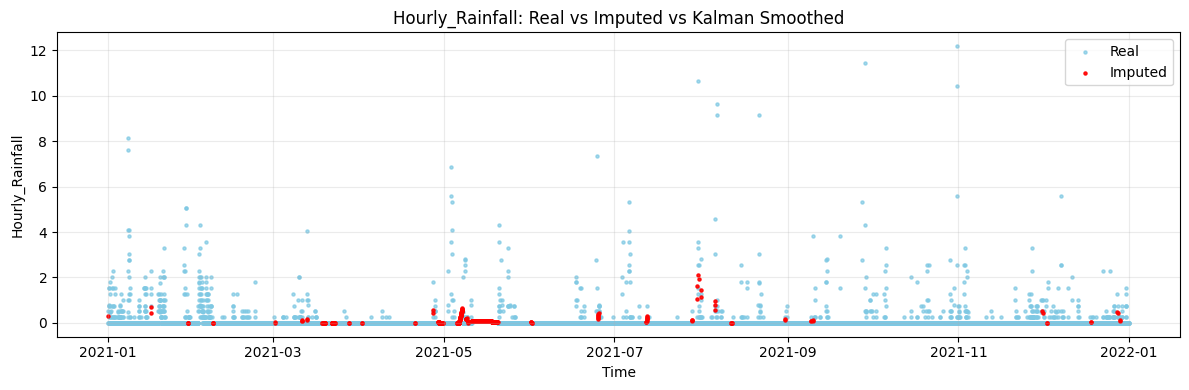

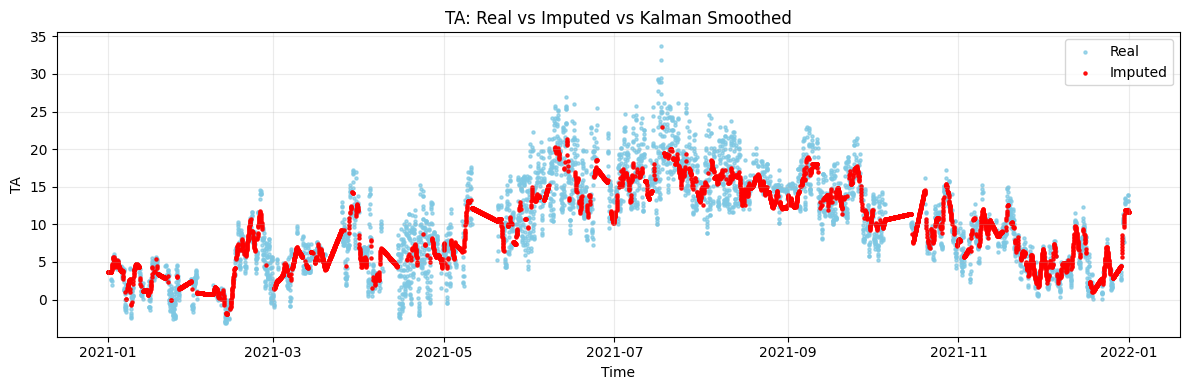

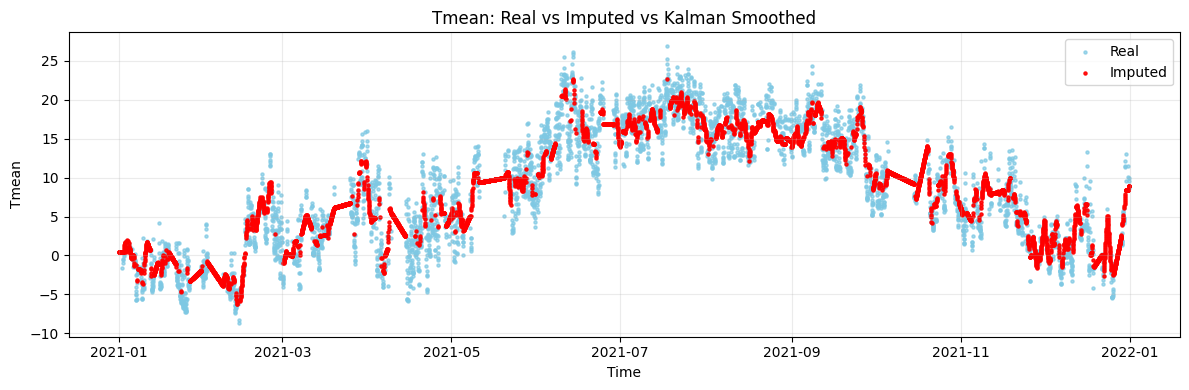

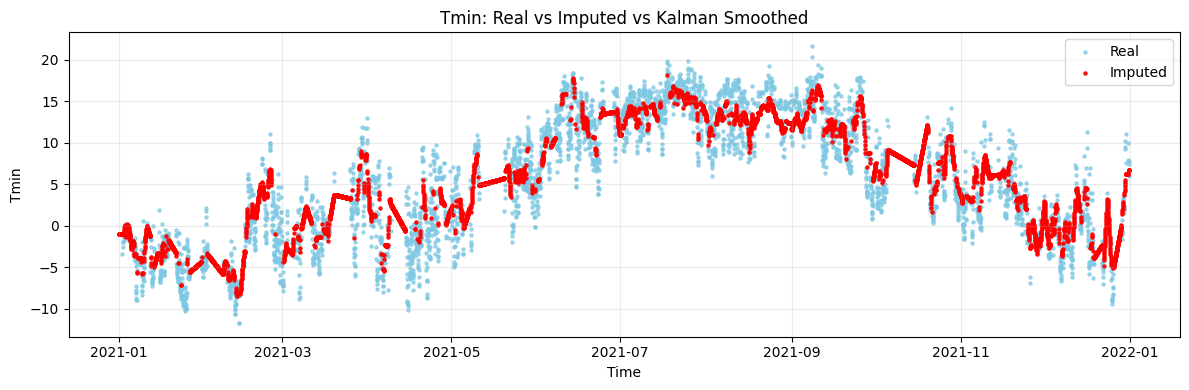

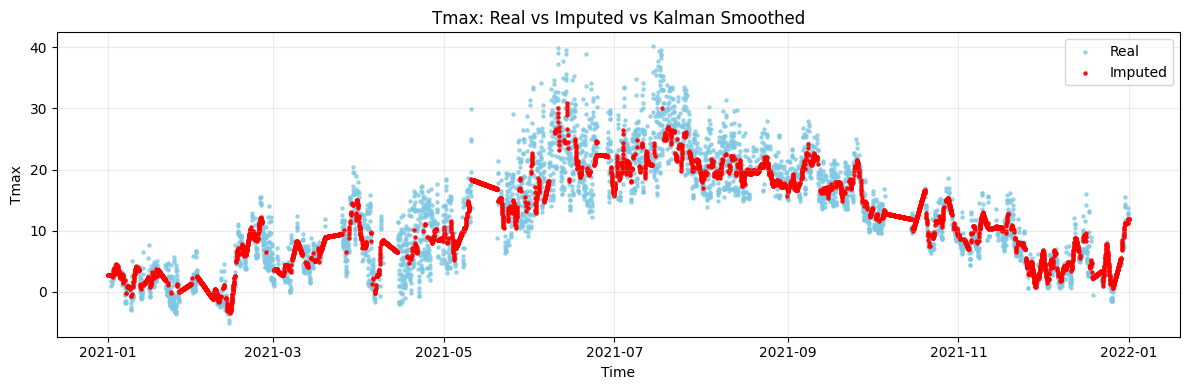

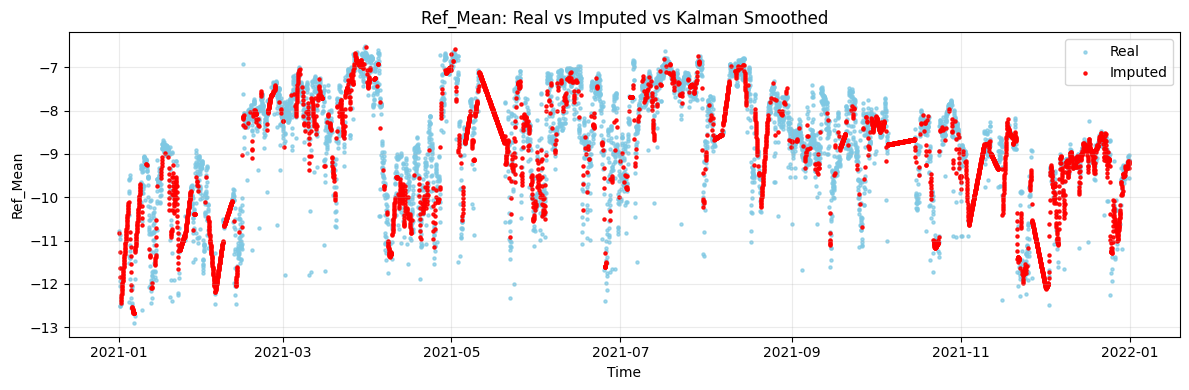

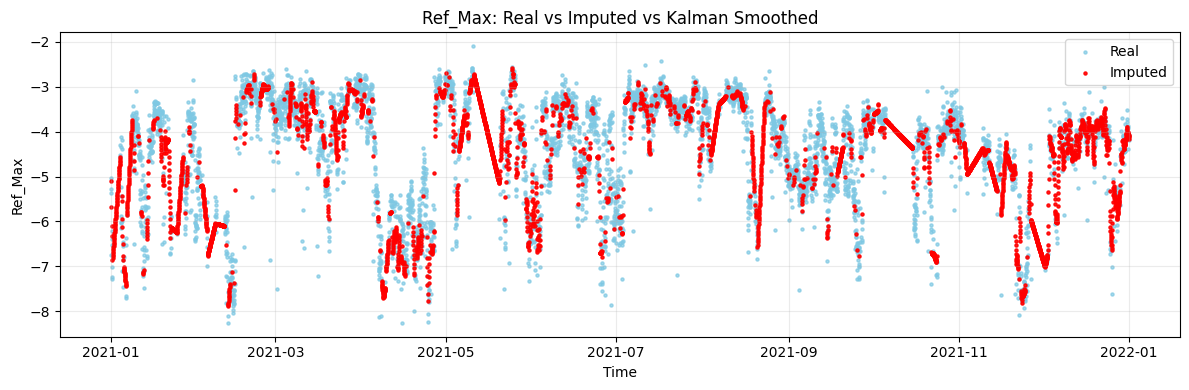

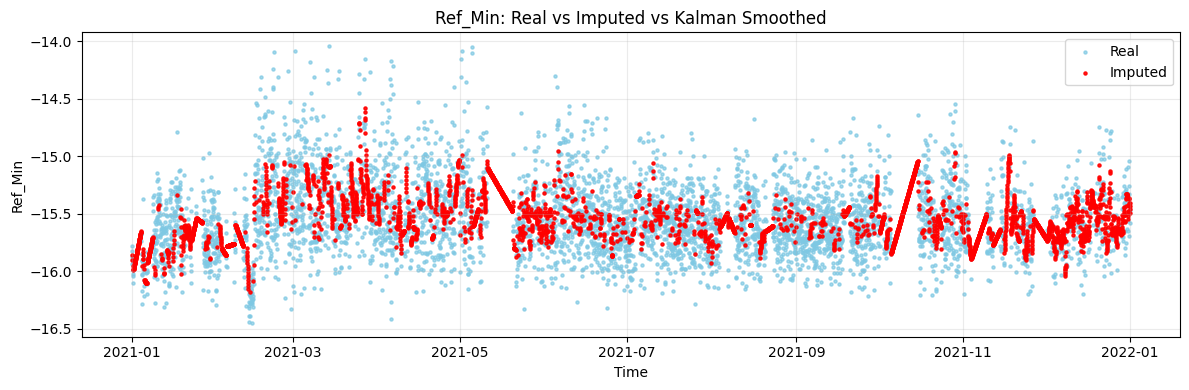

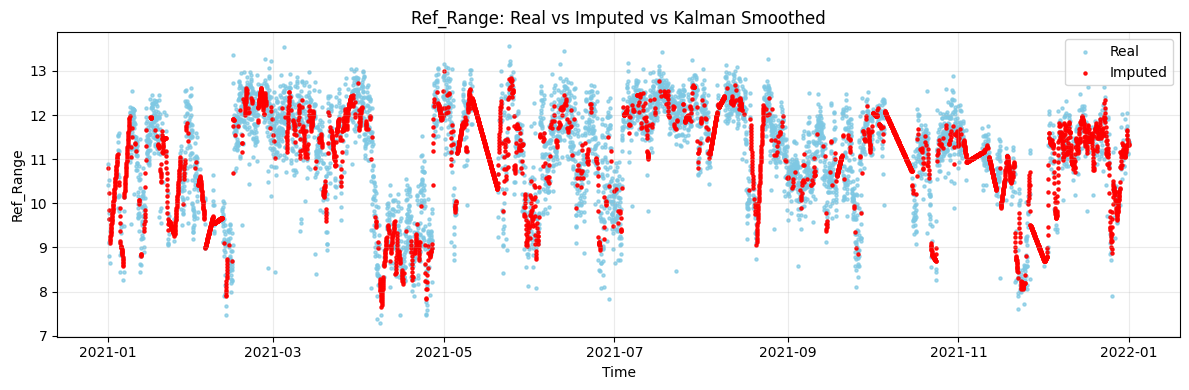

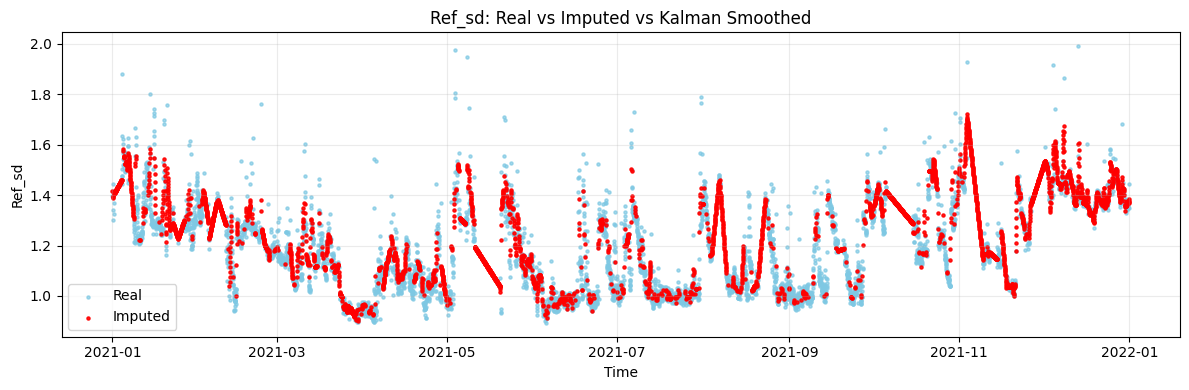

In [44]:
#@title Codeblock K007: Real (Light Blue) vs Imputed (Red) vs Kalman (Blue)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Only variables that still exist after earlier drops
vars_to_impute = [
    "Air_Temp", "Relative_Humidity", "Hourly_Rainfall",
    "TA", "Tmean", "Tmin", "Tmax",
    "Ref_Mean", "Ref_Max", "Ref_Min", "Ref_Range", "Ref_sd"
]

# Use Datetime if available
x = pd.to_datetime(df["Datetime"]) if "Datetime" in df.columns else df.index

for var in vars_to_impute:
    real_col = f"{var}_Real"
    kalman_col = f"{var}_Kalman"

    plt.figure(figsize=(12, 4))

    # Real values (light blue)
    plt.scatter(
        x[df[real_col] == 1],
        df.loc[df[real_col] == 1, var],
        s=5,
        color="#7EC8E3",
        alpha=0.7,
        label="Real"
    )

    # Imputed values (red)
    plt.scatter(
        x[df[real_col] == 0],
        df.loc[df[real_col] == 0, kalman_col],
        s=5,
        color="red",
        alpha=0.9,
        label="Imputed"
    )

    # Optional: Kalman trajectory (commented out)
    # plt.plot(
    #     x,
    #     df[kalman_col],
    #     color="#252525",
    #     linewidth=0.5,
    #     alpha=0.5,
    #     label="Kalman Smoothed"
    # )

    plt.title(f"{var}: Real vs Imputed vs Kalman Smoothed")
    plt.xlabel("Time")
    plt.ylabel(var)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

In [45]:
#@title Codeblock K011: Missing & Imputed Value Diagnostics

import pandas as pd

# Only variables that still exist after earlier drops
vars_to_impute = [
    "Air_Temp", "Relative_Humidity", "Hourly_Rainfall",
    "TA", "Tmean", "Tmin", "Tmax",
    "Ref_Mean", "Ref_Max", "Ref_Min", "Ref_Range", "Ref_sd"
]

diagnostics = []

for var in vars_to_impute:
    real_col = f"{var}_Real"

    total = len(df)
    real_count = df[real_col].sum()
    imputed_count = total - real_count
    missing_original = df[var].isna().sum()

    diagnostics.append({
        "Variable": var,
        "Original Missing Count": missing_original,
        "Imputed Count": imputed_count,
        "Imputed %": round(100 * imputed_count / total, 2)
    })

impute_summary = pd.DataFrame(diagnostics)

print("\nKalman Imputation Diagnostics:\n")
print(impute_summary)


Kalman Imputation Diagnostics:

             Variable  Original Missing Count  Imputed Count  Imputed %
0            Air_Temp                     384            384       4.38
1   Relative_Humidity                     384            384       4.38
2     Hourly_Rainfall                     430            430       4.91
3                  TA                    4689           4689      53.53
4               Tmean                    4689           4689      53.53
5                Tmin                    4689           4689      53.53
6                Tmax                    4689           4689      53.53
7            Ref_Mean                    3838           3838      43.81
8             Ref_Max                    3838           3838      43.81
9             Ref_Min                    3838           3838      43.81
10          Ref_Range                    3838           3838      43.81
11             Ref_sd                    3838           3838      43.81


In [46]:
#@title Codeblock K012: Check for Complete Hourly Coverage in 2021

import pandas as pd

# Ensure datetime + sort
df["Datetime"] = pd.to_datetime(df["Datetime"])
df_sorted = df.sort_values("Datetime")

# Expected hourly timestamps for 2021
expected = pd.date_range(
    start="2021-01-01 00:00:00",
    end="2021-12-31 23:00:00",
    freq="H"
)

# Actual timestamps
actual = df_sorted["Datetime"]

# Missing + duplicates
missing = expected.difference(actual)
duplicates = actual[actual.duplicated()]

print("=== Hourly Timestamp Coverage Diagnostics ===\n")
print(f"Expected rows:  {len(expected)}")
print(f"Actual rows:    {len(actual)}")
print(f"Missing rows:   {len(missing)}")
print(f"Duplicate rows: {len(duplicates)}\n")

if len(missing) == 0 and len(duplicates) == 0:
    print("✔️ Dataset has complete hourly coverage for 2021.")
else:
    print("⚠️ Dataset is NOT complete.\n")

    if len(missing) > 0:
        print("Missing timestamps:")
        print(missing)

    if len(duplicates) > 0:
        print("\nDuplicate timestamps:")
        print(duplicates)

=== Hourly Timestamp Coverage Diagnostics ===

Expected rows:  8760
Actual rows:    8760
Missing rows:   0
Duplicate rows: 0

✔️ Dataset has complete hourly coverage for 2021.


/tmp/ipykernel_4359/779352959.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  expected = pd.date_range(


In [47]:
#@title Codeblock K015: List All Variable Names

print("Variable names in dataframe:\n")
for col in df.columns:
    print(col)

Variable names in dataframe:

Datetime
Gap_Rockfall
Gap_hours
Rockfall_Volume
Volume_Error
Rockfall_Event_Count
Air_Temp
Relative_Humidity
Hourly_Rainfall
TA
Tmean
Tmin
Tmax
Ref_Mean
Ref_Max
Ref_Min
Ref_Range
Ref_sd
Air_Temp_Real
Air_Temp_Kalman
Relative_Humidity_Real
Relative_Humidity_Kalman
Hourly_Rainfall_Real
Hourly_Rainfall_Kalman
TA_Real
TA_Kalman
Tmean_Real
Tmean_Kalman
Tmin_Real
Tmin_Kalman
Tmax_Real
Tmax_Kalman
Ref_Mean_Real
Ref_Mean_Kalman
Ref_Max_Real
Ref_Max_Kalman
Ref_Min_Real
Ref_Min_Kalman
Ref_Range_Real
Ref_Range_Kalman
Ref_sd_Real
Ref_sd_Kalman


In [48]:
#@title Codeblock K016: Cyclical Positional Encodings for Datetime

import numpy as np
import pandas as pd

# Ensure datetime
df["Datetime"] = pd.to_datetime(df["Datetime"])

# Extract components
df["Hour"] = df["Datetime"].dt.hour + df["Datetime"].dt.minute/60
df["DayOfYear"] = df["Datetime"].dt.dayofyear + df["Hour"]/24

# Constants
HOURS_IN_DAY = 24
DAYS_IN_YEAR = 365.25

# Daily cycle (24h)
df["Day_Sin"] = np.sin(2 * np.pi * df["Hour"] / HOURS_IN_DAY)
df["Day_Cos"] = np.cos(2 * np.pi * df["Hour"] / HOURS_IN_DAY)

# Annual cycle (365.25 days)
df["Date_Sin"] = np.sin(2 * np.pi * df["DayOfYear"] / DAYS_IN_YEAR)
df["Date_Cos"] = np.cos(2 * np.pi * df["DayOfYear"] / DAYS_IN_YEAR)

print("Generated cyclical positional encodings: Day_Sin, Day_Cos, Date_Sin, Date_Cos")
df[["Datetime", "Day_Sin", "Day_Cos", "Date_Sin", "Date_Cos"]].head()

Generated cyclical positional encodings: Day_Sin, Day_Cos, Date_Sin, Date_Cos


,Datetime,Day_Sin,Day_Cos,Date_Sin,Date_Cos
0,2021-01-01 00:00:00,0.000000,1.000000,0.017202,0.999852
1,2021-01-01 01:00:00,0.258819,0.965926,0.017918,0.999839
2,2021-01-01 02:00:00,0.500000,0.866025,0.018635,0.999826
3,2021-01-01 03:00:00,0.707107,0.707107,0.019352,0.999813
4,2021-01-01 04:00:00,0.866025,0.500000,0.020068,0.999799


In [49]:
#@title Codeblock K017: Numerical Encoding for Gap_Rockfall (Updated)

import numpy as np
import pandas as pd

# Ensure object dtype for mapping
df["Gap_Rockfall"] = df["Gap_Rockfall"].astype("object")

# Updated mapping:
# 0 = inside gap (NaN)
# 1 = first scan after gap ("Gap")
# 2 = normal valid scan ("NoGap")
mapping = {
    "Gap": 1,
    "NoGap": 2,
    np.nan: 0
}

df["Gap_Code"] = df["Gap_Rockfall"].map(mapping)

# Binary mask: 1 = inside gap, 0 = otherwise
df["InGap"] = (df["Gap_Code"] == 0).astype(int)

print("Created Gap_Code (0/1/2) and InGap (binary) encodings.")
df[["Datetime", "Gap_Rockfall", "Gap_Code", "InGap"]].head()

Created Gap_Code (0/1/2) and InGap (binary) encodings.


,Datetime,Gap_Rockfall,Gap_Code,InGap
0,2021-01-01 00:00:00,NaN,0,1
1,2021-01-01 01:00:00,NoGap,2,0
2,2021-01-01 02:00:00,NoGap,2,0
3,2021-01-01 03:00:00,NoGap,2,0
4,2021-01-01 04:00:00,NaN,0,1


In [50]:
#@title Codeblock K018: Encode Gap_hours (NaN → 0, values preserved)

import pandas as pd
import numpy as np

# Create a new encoded variable with NaN replaced by 0
df["Gap_hours_Encoded"] = df["Gap_hours"].fillna(0)

print("Created Gap_hours_Encoded with NaN replaced by 0 and all values preserved.")
df[["Datetime", "Gap_hours", "Gap_hours_Encoded"]].head(20)

Created Gap_hours_Encoded with NaN replaced by 0 and all values preserved.


,Datetime,Gap_hours,Gap_hours_Encoded
0,2021-01-01 00:00:00,NaN,0.0
1,2021-01-01 01:00:00,NaN,0.0
2,2021-01-01 02:00:00,NaN,0.0
3,2021-01-01 03:00:00,NaN,0.0
4,2021-01-01 04:00:00,NaN,0.0
5,2021-01-01 05:00:00,NaN,0.0
6,2021-01-01 06:00:00,NaN,0.0
7,2021-01-01 07:00:00,NaN,0.0
8,2021-01-01 08:00:00,NaN,0.0
9,2021-01-01 09:00:00,6.0,6.0


In [51]:
#@title K020: Missingness Diagnostics for Output Variables

import pandas as pd

output_vars = [
    "Rockfall_Volume",
    "Volume_Error",
    "Rockfall_Event_Count"
]

diagnostics = []

for var in output_vars:
    missing = df[var].isna().sum()
    total = len(df)
    diagnostics.append({
        "Variable": var,
        "Missing Count": missing,
        "Missing %": round(100 * missing / total, 2)
    })

missing_summary = pd.DataFrame(diagnostics)

print("\nMissingness Diagnostics for Output Variables:\n")
print(missing_summary)


Missingness Diagnostics for Output Variables:

               Variable  Missing Count  Missing %
0       Rockfall_Volume           3567      40.72
1          Volume_Error           3567      40.72
2  Rockfall_Event_Count           3567      40.72


In [52]:
#@title K021: Create _Real Flags for Output Variables

for var in output_vars:
    df[f"{var}_Real"] = df[var].notna().astype(int)

print("Created _Real flags for output variables.")
df[[f"{v}_Real" for v in output_vars]].head()

Created _Real flags for output variables.


,Rockfall_Volume_Real,Volume_Error_Real,Rockfall_Event_Count_Real
0,0,0,0
1,1,1,1
2,1,1,1
3,1,1,1
4,0,0,0


In [53]:
#@title K022: Kalman Imputation for Output Variables

import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.structural import UnobservedComponents

def estimate_Q(series):
    diffs = series.diff().dropna()
    return np.nanvar(diffs)

def estimate_R(series):
    med = series.rolling(window=24, center=True, min_periods=1).median()
    residuals = series - med
    return np.nanvar(residuals)

def seasonal_kalman_smooth(series, Q, R, seasonal_period=24):
    model = UnobservedComponents(
        series,
        level="local level",
        seasonal=seasonal_period
    )
    model.update(model.start_params)
    params = model.start_params.copy()
    params[0] = R
    params[1] = Q
    params[2] = Q
    result = model.smooth(params)
    return pd.Series(result.smoothed_state[0], index=series.index)

for var in output_vars:
    print(f"Processing {var}...")

    real_col = f"{var}_Real"
    kalman_col = f"{var}_Kalman"

    s = df[var].astype(float)

    Q = estimate_Q(s)
    R = estimate_R(s)

    smoothed = seasonal_kalman_smooth(s, Q, R, seasonal_period=24)

    observed_min = s.min()
    observed_max = s.max()
    smoothed_clipped = smoothed.clip(lower=observed_min, upper=observed_max)

    df[kalman_col] = np.where(df[real_col] == 1, s, smoothed_clipped)

print("\nOutput variable Kalman smoothing complete.")

Processing Rockfall_Volume...
Processing Volume_Error...
Processing Rockfall_Event_Count...

Output variable Kalman smoothing complete.


In [54]:
#@title K023: Imputation Diagnostics for Output Variables

diagnostics = []

for var in output_vars:
    real_col = f"{var}_Real"
    total = len(df)
    real_count = df[real_col].sum()
    imputed_count = total - real_count
    missing_original = df[var].isna().sum()

    diagnostics.append({
        "Variable": var,
        "Original Missing Count": missing_original,
        "Imputed Count": imputed_count,
        "Imputed %": round(100 * imputed_count / total, 2)
    })

output_impute_summary = pd.DataFrame(diagnostics)

print("\nKalman Imputation Diagnostics for Output Variables:\n")
print(output_impute_summary)


Kalman Imputation Diagnostics for Output Variables:

               Variable  Original Missing Count  Imputed Count  Imputed %
0       Rockfall_Volume                    3567           3567      40.72
1          Volume_Error                    3567           3567      40.72
2  Rockfall_Event_Count                    3567           3567      40.72


In [55]:
#@title Codeblock K025: Drop Specified Variables from DataFrame

cols_to_drop = [
    "Gap_Rockfall",
    "Gap_hours",
    "Rockfall_Volume",
    "Volume_Error",
    "Rockfall_Event_Count",
    "Air_Temp",
    "Relative_Humidity",
    "Hourly_Rainfall",
    "Hour",
    "TA",
    "Tmean",
    "Tmin",
    "Tmax",
    "Ref_Mean",
    "Ref_Max",
    "Ref_Min",
    "Ref_Range",
    "Ref_sd"
]

df = df.drop(columns=cols_to_drop)

print("Dropped specified variables from dataframe.")
df.info()

Dropped specified variables from dataframe.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Datetime                     8760 non-null   datetime64[ns]
 1   Air_Temp_Real                8760 non-null   int64         
 2   Air_Temp_Kalman              8760 non-null   float64       
 3   Relative_Humidity_Real       8760 non-null   int64         
 4   Relative_Humidity_Kalman     8760 non-null   float64       
 5   Hourly_Rainfall_Real         8760 non-null   int64         
 6   Hourly_Rainfall_Kalman       8760 non-null   float64       
 7   TA_Real                      8760 non-null   int64         
 8   TA_Kalman                    8760 non-null   float64       
 9   Tmean_Real                   8760 non-null   int64         
 10  Tmean_Kalman                 8760 non-null   float64       
 11 

In [57]:
#@title K026 (Emoji Edition): Data Integrity Checks

import pandas as pd
import numpy as np

print("\n🔍 **1. Checking that all non-Datetime columns are numeric...**\n")

non_numeric = df.drop(columns=["Datetime"]).select_dtypes(exclude=[np.number]).columns.tolist()

if len(non_numeric) == 0:
    print("✅ All variables except 'Datetime' are numeric.")
else:
    print("❌ Non-numeric columns detected:")
    for col in non_numeric:
        print(f"   • {col}")


print("\n⏱️ **2. Checking hourly continuity across the full timeframe...**\n")

# Ensure Datetime is datetime type
df["Datetime"] = pd.to_datetime(df["Datetime"])

# Build complete hourly index
full_range = pd.date_range(start=df["Datetime"].min(),
                           end=df["Datetime"].max(),
                           freq="H")

missing_hours = full_range.difference(df["Datetime"])

if len(missing_hours) == 0:
    print("✅ No missing hourly timestamps — full hourly coverage confirmed.")
else:
    print(f"❌ Missing {len(missing_hours)} hourly timestamps.")
    print("   Example missing hours:")
    print(missing_hours[:10])


print("\n🧩 **3. Checking for any remaining missing data in the dataframe...**\n")

missing_counts = df.isna().sum()
total_missing = missing_counts.sum()

if total_missing == 0:
    print("✅ No missing values remain in the dataframe.")
else:
    print(f"❌ Missing values detected: {total_missing} total")
    print("Columns with missing values:")
    print(missing_counts[missing_counts > 0])


🔍 **1. Checking that all non-Datetime columns are numeric...**

✅ All variables except 'Datetime' are numeric.

⏱️ **2. Checking hourly continuity across the full timeframe...**

✅ No missing hourly timestamps — full hourly coverage confirmed.

🧩 **3. Checking for any remaining missing data in the dataframe...**

✅ No missing values remain in the dataframe.


/tmp/ipykernel_4359/3038640332.py:24: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(start=df["Datetime"].min(),


In [58]:
#@title K027: Export Model_Ready_Imputed_Rockfall_Data to Google Drive

# Define target directory
target_dir = "/content/drive/MyDrive/Masters_Colab_Data"

# Create folder if it doesn't exist
os.makedirs(target_dir, exist_ok=True)

# Define output path with your chosen dataset name
output_path = f"{target_dir}/Model_Ready_Imputed_Rockfall_Data.xlsx"

# Export to Excel
df.to_excel(output_path, index=False)

print(f"✅ DataFrame exported successfully to:\n{output_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ DataFrame exported successfully to:
/content/drive/MyDrive/Masters_Colab_Data/Model_Ready_Imputed_Rockfall_Data.xlsx
